## RPM 예측 모델

- Train1~4의 초반 2시간 데이터(1시간 단위 RPM 변화)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import glob, os
from nptdms import TdmsFile
from scipy.stats import kurtosis
from scipy.fft import fft, fftfreq

In [9]:
def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.family'] = 'AppleGothic'
    else:  # Linux (서버 환경)
        # 나눔 폰트 설치 후 사용
        # sudo apt-get install fonts-nanum
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                      capture_output=True)
        fm._load_fontmanager(try_read_cache=False)
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        font_prop = fm.FontProperties(fname=font_path)
        plt.rcParams['font.family'] = font_prop.get_name()

    plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

set_korean_font()

In [2]:
# !pip install xgboost

## 통계 피쳐 추가

In [26]:
FS        = 25600
WIN       = FS
BASE_PATH = '../data/Train'

FAULT_FREQ = {'BPFI': 140, 'BPFO': 93, 'BSF': 78, 'Cage': 6.7}
FAULT_BW   = {'BPFI': 8,   'BPFO': 6,  'BSF': 6,  'Cage': 1.5}
CH_NAMES   = ['ch1', 'ch2', 'ch3', 'ch4']


# ── RPM 로드 (Train 전용) ─────────────────────────────────────
def load_rpm(train_num, base_path=BASE_PATH):
    path = os.path.join(base_path, f'Train{train_num}_Operation.csv')
    df   = pd.read_csv(path, encoding='cp949')
    df.columns = [c.strip() for c in df.columns]
    return df.set_index(df.columns[0])[df.columns[2]]


def epoch_rpm(rpm_series, f_num):
    t0  = (f_num - 1) * 600
    t1  = t0 + 60
    sub = rpm_series[(rpm_series.index >= t0) & (rpm_series.index <= t1)]
    return float(sub.mean()) if len(sub) > 0 else 850.0


# ── 시간 도메인 피처 ──────────────────────────────────────────
def time_features_1sec(sig):
    rms      = np.sqrt(np.mean(sig ** 2))
    peak     = np.max(np.abs(sig))
    mean_abs = np.mean(np.abs(sig)) + 1e-10
    return {
        'rms':            rms,
        'kurtosis':       kurtosis(sig, fisher=True),
        'peak2peak':      np.ptp(sig),
        'crest_factor':   peak / (rms + 1e-10),
        'shape_factor':   rms / mean_abs,
        'impulse_factor': peak / mean_abs,
    }


# ── 주파수 도메인 피처 ────────────────────────────────────────
def freq_features_1sec(sig, rpm):
    N     = len(sig)
    freqs = fftfreq(N, 1/FS)[:N//2]
    mag   = np.abs(fft(sig))[:N//2]
    power = mag ** 2
    total = np.sum(power) + 1e-10
    scale = rpm / 1000

    result = {}

    result['spectral_centroid'] = np.sum(freqs * power) / total

    np_norm = power / total
    np_norm = np_norm[np_norm > 0]
    result['spectral_entropy'] = -np.sum(np_norm * np.log2(np_norm))

    for name, fc in FAULT_FREQ.items():
        bw   = FAULT_BW[name]
        band = (freqs >= fc * scale - bw) & (freqs <= fc * scale + bw)
        result[f'fault_{name}'] = (
            np.sum(power[band]) / band.sum() if band.sum() > 0 else 0.0
        )

    return result


# ── TDMS → 1초 단위 피처 추출 ────────────────────────────────
def extract_features(tdms_path, f_num, rpm_actual, is_validation=False):
    with TdmsFile.read(tdms_path) as tdms:
        ch_data = {ch.name: ch[:].astype(np.float32)
                   for ch in tdms.groups()[0].channels()}

    signals   = [ch_data[f'CH{i+1}'] for i in range(4)]
    n_windows = len(signals[0]) // WIN

    # Train: labeled tdms에서 ttf/RUL 읽기
    # Validation: ttf/RUL 없음
    if not is_validation:
        ttf     = float(ch_data['ttf'][0])
        rul_arr = ch_data['RUL']
    else:
        ttf     = None
        rul_arr = None

    rows = []
    for w in range(n_windows):
        start = w * WIN
        end   = start + WIN
        mid   = (start + end) // 2
        t_abs = (f_num - 1) * 600 + w + 0.5

        row = {
            'epoch':  f_num,
            'window': w,
            't_abs':  t_abs,
            'rpm':    rpm_actual,  # Train: 실측값 / Validation: None
        }

        # Train 전용 컬럼
        if not is_validation:
            row['ttf']      = ttf
            row['RUL']      = float(rul_arr[mid])
            row['life_pct'] = t_abs / ttf * 100

        for i, sig_full in enumerate(signals):
            sig = sig_full[start:end]
            tag = CH_NAMES[i]
            for k, v in time_features_1sec(sig).items():
                row[f'{tag}_{k}'] = v
            for k, v in freq_features_1sec(sig, rpm_actual).items():
                row[f'{tag}_{k}'] = v

        rows.append(row)
    return rows


# ── 전체 실행 ─────────────────────────────────────────────────
def build_featured_csv(data_num, is_validation=False):
    if is_validation:
        vib_dir   = os.path.join('../data/Validation',
                                 f'Validation{data_num}_Vibration')
        file_pattern = os.path.join(vib_dir, '*.tdms')
        rpm_series   = None          # Validation: rpm 없음
        rpm_default  = 850.0         # 고장 주파수 보정 fallback
    else:
        vib_dir      = os.path.join(BASE_PATH, f'Train{data_num}_Vibration')
        file_pattern = os.path.join(vib_dir, '*_labeled.tdms')
        rpm_series   = load_rpm(data_num)  # Train: 실측 rpm 로드
        rpm_default  = None

    files = sorted(
        [f for f in glob.glob(file_pattern)],
        key=lambda x: int(os.path.basename(x).split('_')[0]
                          if not is_validation
                          else os.path.basename(x).split('.')[0])
    )

    all_rows = []
    for fpath in files:
        fname = os.path.basename(fpath)
        f_num = int(fname.split('_')[0] if not is_validation
                    else fname.split('.')[0])

        # rpm_actual 결정
        if is_validation:
            rpm_actual = rpm_default   # Validation: 850 고정
        else:
            rpm_actual = epoch_rpm(rpm_series, f_num)

        rows = extract_features(fpath, f_num, rpm_actual, is_validation)
        all_rows.extend(rows)

    df = pd.DataFrame(all_rows)

    if is_validation:
        save_path = (f'../data/Validation/'
                     f'Validation{data_num}_vibration_featured.csv')
    else:
        save_path = f'{BASE_PATH}/Train{data_num}_vibration_featured.csv'

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

    label = 'Validation' if is_validation else 'Train'
    print(f'{label} {data_num}: {len(df)}행 저장 → {save_path}')
    return df


# ── 실행 ─────────────────────────────────────────────────────
# Train
all_df = {}
for t in [1, 2, 3, 4]:
    all_df[t] = build_featured_csv(t, is_validation=False)

# Validation (데이터 수령 후)
# for v in [1, 2, ...]:
#     build_featured_csv(v, is_validation=True)

# ── 피처 확인 ─────────────────────────────────────────────────
print('\n=== 피처 목록 ===')
meta      = ['epoch', 'window', 't_abs', 'rpm', 'ttf', 'RUL', 'life_pct']
feat_cols = [c for c in all_df[1].columns if c not in meta]
print(f'총 {len(feat_cols)}개: {feat_cols}')

Train 1: 7560행 저장 → ../data/Train/Train1_vibration_featured.csv
Train 2: 6840행 저장 → ../data/Train/Train2_vibration_featured.csv
Train 3: 5340행 저장 → ../data/Train/Train3_vibration_featured.csv
Train 4: 8220행 저장 → ../data/Train/Train4_vibration_featured.csv

=== 피처 목록 ===
총 48개: ['ch1_rms', 'ch1_kurtosis', 'ch1_peak2peak', 'ch1_crest_factor', 'ch1_shape_factor', 'ch1_impulse_factor', 'ch1_spectral_centroid', 'ch1_spectral_entropy', 'ch1_fault_BPFI', 'ch1_fault_BPFO', 'ch1_fault_BSF', 'ch1_fault_Cage', 'ch2_rms', 'ch2_kurtosis', 'ch2_peak2peak', 'ch2_crest_factor', 'ch2_shape_factor', 'ch2_impulse_factor', 'ch2_spectral_centroid', 'ch2_spectral_entropy', 'ch2_fault_BPFI', 'ch2_fault_BPFO', 'ch2_fault_BSF', 'ch2_fault_Cage', 'ch3_rms', 'ch3_kurtosis', 'ch3_peak2peak', 'ch3_crest_factor', 'ch3_shape_factor', 'ch3_impulse_factor', 'ch3_spectral_centroid', 'ch3_spectral_entropy', 'ch3_fault_BPFI', 'ch3_fault_BPFO', 'ch3_fault_BSF', 'ch3_fault_Cage', 'ch4_rms', 'ch4_kurtosis', 'ch4_peak2peak',

### 진동 데이터 > 샤프트 주파수 방법

- 베어링이 회전하면 샤프트도 같이 회전하는데 샤프트가 1초에 N번 회전하면 진동 신호에 Nhz 성분이 나타남         
ex. 750rpm = 1분에 750번 회전 = 1초에 12.5회전 > 진동 신호 FFT에서 12.5hz 피크가 발생

Train 1: 7560행 완료
Train 2: 6840행 완료
Train 3: 5340행 완료
Train 4: 8220행 완료

=== RPM 예측 성능 ===
Train 1 | MAE=110.0 RPM | 저속/고속 분류 정확도=62.1%
Train 2 | MAE=78.4 RPM | 저속/고속 분류 정확도=80.0%
Train 3 | MAE=81.6 RPM | 저속/고속 분류 정확도=77.3%
Train 4 | MAE=120.1 RPM | 저속/고속 분류 정확도=49.5%


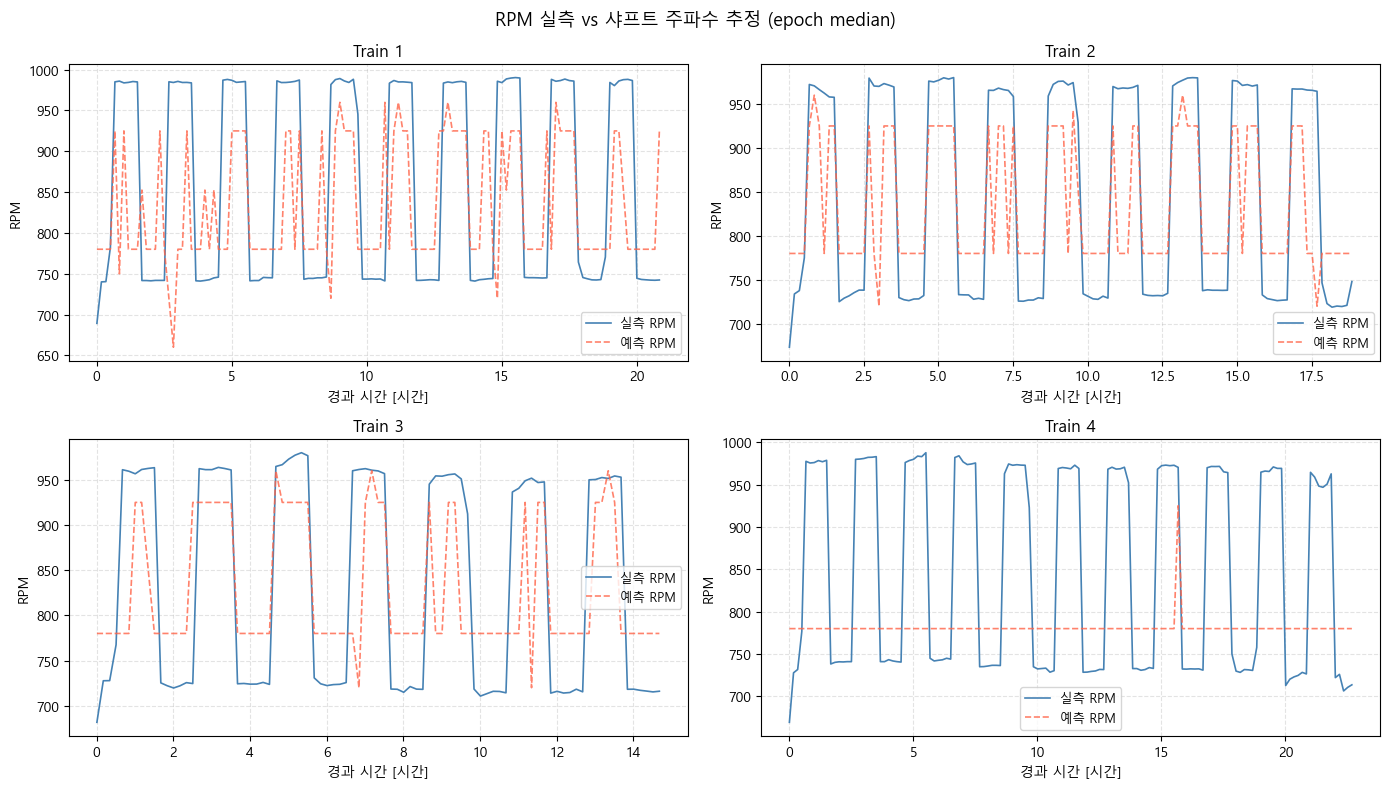

In [27]:
FS        = 25600
WIN       = FS
BASE_PATH = '../data/Train'


# ──────────────────────────────────────────────
# 샤프트 주파수 탐지 → RPM 추정
# ──────────────────────────────────────────────
def estimate_rpm_from_signal(sig, fs=FS):
    """
    진동 신호 FFT에서 샤프트 회전 주파수 피크 탐지
    탐색 범위: 650~1010rpm → 10.8~16.8Hz
    """
    N     = len(sig)
    freqs = fftfreq(N, 1/fs)[:N//2]
    mag   = np.abs(fft(sig))[:N//2]

    # 샤프트 주파수 탐색 범위
    mask = (freqs >= 10.8) & (freqs <= 16.8)
    if mask.sum() == 0:
        return 850.0

    peak_freq = freqs[mask][np.argmax(mag[mask])]
    rpm_est   = peak_freq * 60

    # 물리적 범위 클리핑 + 저속/고속 구간 보정
    if rpm_est < 825:
        return float(np.clip(rpm_est, 650, 800))
    else:
        return float(np.clip(rpm_est, 925, 1010))


# ──────────────────────────────────────────────
# RPM 로드 (실측)
# ──────────────────────────────────────────────
def load_rpm(train_num):
    path = os.path.join(BASE_PATH, f'Train{train_num}_Operation.csv')
    df   = pd.read_csv(path, encoding='cp949')
    df.columns = [c.strip() for c in df.columns]
    return df.set_index(df.columns[0])[df.columns[2]]


def epoch_rpm(rpm_series, f_num):
    t0  = (f_num - 1) * 600
    t1  = t0 + 60
    sub = rpm_series[(rpm_series.index >= t0) & (rpm_series.index <= t1)]
    return float(sub.mean()) if len(sub) > 0 else 850.0


# ──────────────────────────────────────────────
# TDMS에서 1초 단위 rpm_pred 추출
# ──────────────────────────────────────────────
def extract_rpm_pred(train_num):
    vib_dir = os.path.join(BASE_PATH, f'Train{train_num}_Vibration')
    files   = sorted(
        [f for f in glob.glob(os.path.join(vib_dir, '*_labeled.tdms'))],
        key=lambda x: int(os.path.basename(x).split('_')[0])
    )
    rpm_series = load_rpm(train_num)

    rows = []
    for fpath in files:
        f_num      = int(os.path.basename(fpath).split('_')[0])
        rpm_actual = epoch_rpm(rpm_series, f_num)

        with TdmsFile.read(fpath) as tdms:
            ch1 = tdms.groups()[0].channels()[0][:].astype(np.float32)

        n_windows = len(ch1) // WIN
        for w in range(n_windows):
            sig      = ch1[w*WIN:(w+1)*WIN]
            rpm_pred = estimate_rpm_from_signal(sig)
            t_abs    = (f_num - 1) * 600 + w + 0.5

            rows.append({
                'epoch':      f_num,
                'window':     w,
                't_abs':      t_abs,
                'rpm_actual': rpm_actual,
                'rpm_pred':   rpm_pred,
            })

    df = pd.DataFrame(rows)
    print(f'Train {train_num}: {len(df)}행 완료')
    return df


# ──────────────────────────────────────────────
# 실행 및 비교
# ──────────────────────────────────────────────
rpm_dfs = {}
for t in [1, 2, 3, 4]:
    rpm_dfs[t] = extract_rpm_pred(t)

# ── 성능 지표 ─────────────────────────────────
print('\n=== RPM 예측 성능 ===')
for t, df in rpm_dfs.items():
    mae = (df['rpm_actual'] - df['rpm_pred']).abs().mean()

    # 저속/고속 분류 정확도
    df['actual_class'] = (df['rpm_actual'] > 825).astype(int)
    df['pred_class']   = (df['rpm_pred']   > 825).astype(int)
    acc = (df['actual_class'] == df['pred_class']).mean() * 100

    print(f'Train {t} | MAE={mae:.1f} RPM | 저속/고속 분류 정확도={acc:.1f}%')

# ── 트렌드 시각화 ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('RPM 실측 vs 샤프트 주파수 추정 (epoch median)', fontsize=13)

for idx, (t, df) in enumerate(rpm_dfs.items()):
    ax  = axes[idx // 2][idx % 2]
    grp = df.groupby('epoch').agg(
        t_abs     =('t_abs',      'median'),
        rpm_actual=('rpm_actual', 'median'),
        rpm_pred  =('rpm_pred',   'median'),
    ).sort_values('t_abs')

    ax.plot(grp['t_abs'] / 3600, grp['rpm_actual'],
            label='실측 RPM', linewidth=1.2, color='steelblue')
    ax.plot(grp['t_abs'] / 3600, grp['rpm_pred'],
            label='예측 RPM', linewidth=1.2,
            color='tomato', linestyle='--', alpha=0.8)
    ax.set_title(f'Train {t}')
    ax.set_xlabel('경과 시간 [시간]')
    ax.set_ylabel('RPM')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('./output/rpm_shaft_freq_validation.png', bbox_inches='tight')
plt.show()

In [28]:
# 기존 featured CSV 로드 후 rpm_pred 병합해서 저장
for t in [1, 2, 3, 4]:
    # 기존 featured CSV 로드
    featured_path = f'{BASE_PATH}/Train{t}_vibration_featured.csv'
    df_feat = pd.read_csv(featured_path)

    # rpm_pred 데이터 (epoch, window 기준으로 병합)
    df_rpm = rpm_dfs[t][['epoch', 'window', 'rpm_pred']]

    # 병합
    df_feat = df_feat.merge(df_rpm, on=['epoch', 'window'], how='left')

    # 저장
    df_feat.to_csv(featured_path, index=False)
    print(f'Train {t} 저장 완료 | shape={df_feat.shape} | '
          f'rpm_pred 결측={df_feat["rpm_pred"].isna().sum()}개')

Train 1 저장 완료 | shape=(7560, 56) | rpm_pred 결측=0개
Train 2 저장 완료 | shape=(6840, 56) | rpm_pred 결측=0개
Train 3 저장 완료 | shape=(5340, 56) | rpm_pred 결측=0개
Train 4 저장 완료 | shape=(8220, 56) | rpm_pred 결측=0개


### XGBoost - X : 회귀가 아니라 예측이 어려움

In [10]:
BASE_PATH = '../data/Train'

all_df = {}
for t in [1, 2, 3, 4]:
    all_df[t] = pd.read_csv(f'{BASE_PATH}/Train{t}_vibration_featured.csv')

RPM_FEATS = [
    'ch1_rms',
    'ch2_rms',
    'ch3_rms',
    'ch4_rms',
    'ch1_spectral_centroid',
    'ch2_spectral_centroid',
    'ch3_spectral_centroid',
    'ch4_spectral_centroid',
    'ch1_spectral_entropy',
    'ch2_spectral_entropy',
    'ch3_spectral_entropy',
    'ch4_spectral_entropy',
]

early_all = pd.concat([
    all_df[t][
        all_df[t]['t_abs'] <= 7200
        if all_df[t]['t_abs'].max() >= 7200
        else all_df[t]['life_pct'] <= 50
    ][RPM_FEATS + ['rpm']].assign(train=t)
    for t in [1, 2, 3, 4]
], ignore_index=True)

# 확인
for t, df in all_df.items():
    used = df[
        df['t_abs'] <= 7200
        if df['t_abs'].max() >= 7200
        else df['life_pct'] <= 50
    ]
    method = '2시간' if df['t_abs'].max() >= 7200 else '초반 50%'
    print(f'Train {t}: {method} 사용 | {len(used)}행 | '
          f't_abs 최대={df["t_abs"].max():.0f}s')

Train 1: 2시간 사용 | 720행 | t_abs 최대=75060s
Train 2: 2시간 사용 | 720행 | t_abs 최대=67860s
Train 3: 2시간 사용 | 720행 | t_abs 최대=52860s
Train 4: 2시간 사용 | 720행 | t_abs 최대=81660s



=== Leave-One-Out RPM 예측 성능 ===
  Test=Train1 | MAE=57.8 RPM | R²=0.458
  Test=Train2 | MAE=49.2 RPM | R²=0.703
  Test=Train3 | MAE=76.0 RPM | R²=-0.051
  Test=Train4 | MAE=150.3 RPM | R²=-1.452

평균 MAE: 83.3 RPM | 평균 R²: -0.085


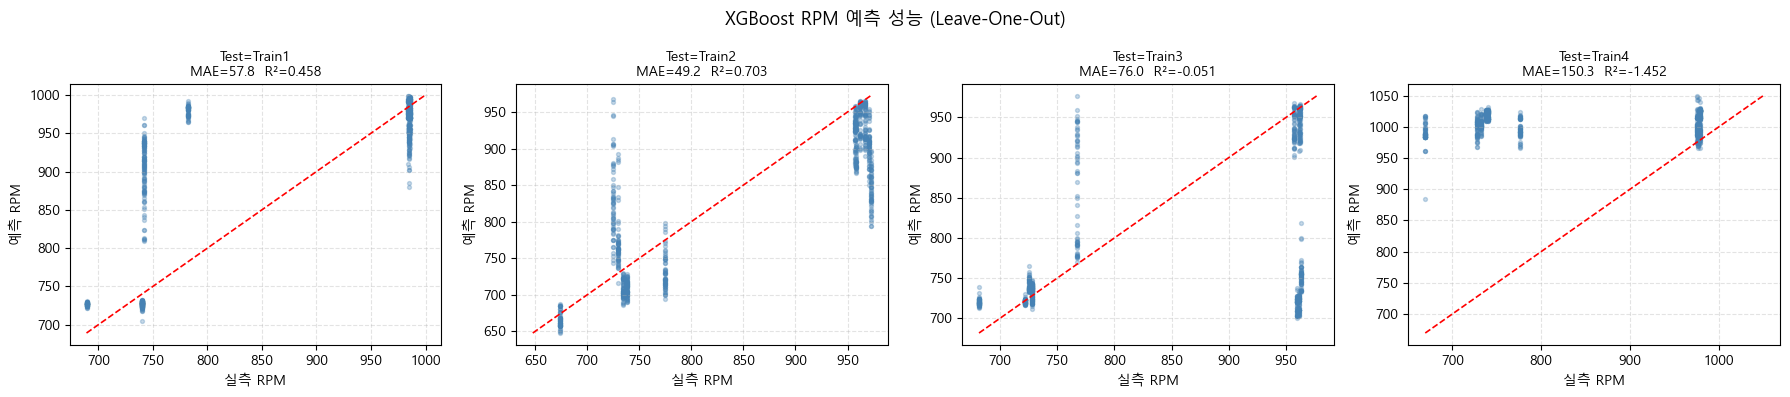

In [11]:
# ── XGBoost 하이퍼파라미터 ────────────────────────────────────
XGB_PARAMS = {
    'n_estimators':  200,
    'max_depth':     4,
    'learning_rate': 0.05,
    'subsample':     0.8,
    'colsample_bytree': 0.8,
    'random_state':  42,
    'verbosity':     0,
}

# ── Leave-One-Out 검증 ────────────────────────────────────────
print('\n=== Leave-One-Out RPM 예측 성능 ===')

loo_results = []
for test_t in [1, 2, 3, 4]:
    train_data = early_all[early_all['train'] != test_t]
    test_data  = early_all[early_all['train'] == test_t]

    X_train = train_data[RPM_FEATS].values
    y_train = train_data['rpm'].values
    X_test  = test_data[RPM_FEATS].values
    y_test  = test_data['rpm'].values

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    print(f'  Test=Train{test_t} | MAE={mae:.1f} RPM | R²={r2:.3f}')

    loo_results.append({
        'test_train': test_t,
        'mae': mae, 'r2': r2,
        'y_test': y_test,
        'y_pred': y_pred,
    })

avg_mae = np.mean([r['mae'] for r in loo_results])
avg_r2  = np.mean([r['r2']  for r in loo_results])
print(f'\n평균 MAE: {avg_mae:.1f} RPM | 평균 R²: {avg_r2:.3f}')

# ── LOO 산점도 시각화 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('XGBoost RPM 예측 성능 (Leave-One-Out)', fontsize=13)

for idx, res in enumerate(loo_results):
    ax = axes[idx]
    ax.scatter(res['y_test'], res['y_pred'],
               alpha=0.3, s=8, color='steelblue')
    mn = min(res['y_test'].min(), res['y_pred'].min())
    mx = max(res['y_test'].max(), res['y_pred'].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.2)
    ax.set_title(
        f'Test=Train{res["test_train"]}\n'
        f'MAE={res["mae"]:.1f}  R²={res["r2"]:.3f}',
        fontsize=10
    )
    ax.set_xlabel('실측 RPM')
    ax.set_ylabel('예측 RPM')
    ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('./output/rpm_xgb_loo.png', bbox_inches='tight')
plt.show()